In [1]:
import pandas as pd
import matplotlib.pyplot as plot

In [3]:
# Ler arquivo
caminho = r'C:\Users\marco\OneDrive\Documents\CS\Intern\PythonNotebook\bootcampia\ex_iris\iris_sujo.csv'

data_frame = pd.read_csv(caminho)


In [4]:
data_frame.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,147.000000,150.000000,147.000000,150.000000
mean,75.500000,5.846259,3.054000,3.761224,1.198667
std,43.445368,0.805654,0.433594,1.763653,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.400000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.700000,4.400000,6.900000,2.500000


In [40]:
# Nome e quantidade de cada espécie 
data_frame["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [ ]:
# Ver todas as colunas, menos o Id
data_frame[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,NaN,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [46]:
# Uma estratégia melhor é já dropar a coluna de "Id" 
# para não ter que filtrar as colunas em todas as buscas

data_frame = data_frame.drop(columns="Id")
data_frame

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,NaN,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [31]:
data_frame.count()

Id               150
SepalLengthCm    147
SepalWidthCm     150
PetalLengthCm    147
PetalWidthCm     150
Species          150
dtype: int64

Nota-se que SepalLength e PetalLength possuem dados faltantes.
- Como é fácil de resolver, compensa arrumar do que deletar essas linhas.

Descobrir quais espécies faltam essas informações
- Faltam uma em cada espécie

Analisar no gráfico de pontos flutuantes a variância dessas medidas

Decidir como preencher os valores faltantes
- mediana, média..?

Atribuir o novo valor

In [28]:
# data_frame[data_frame["Species"] == "Iris-setosa"]

data_frame.loc[data_frame["Species"] == "Iris-setosa", ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm", "Species"]]


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,NaN,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,NaN,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


<Axes: xlabel='Id', ylabel='SepalLengthCm'>

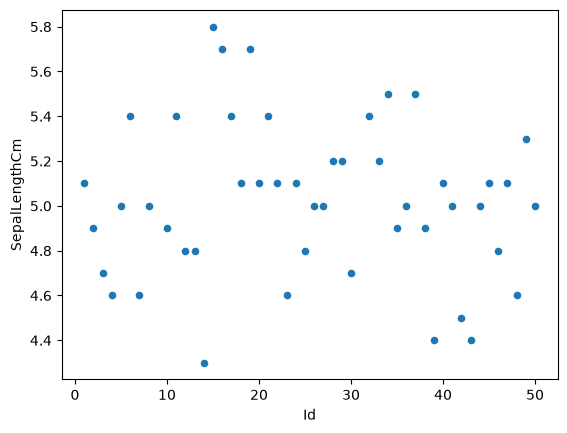

In [ ]:
# Iris-setosa
# Ver gráfico de dispersão (pontos flutuantes)
data_plot = data_frame
data_plot.loc[data_frame["Species"] == "Iris-setosa"].plot.scatter(x="index", y="SepalLengthCm")



<Axes: >

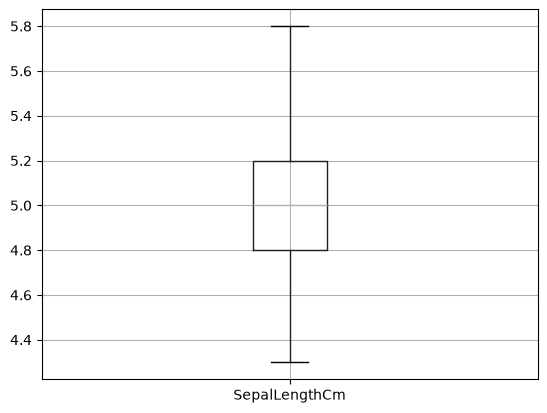

In [44]:
# Iris-setosa
# Ver gráfico de dispersão (pontos flutuantes)
data_plot.loc[data_frame["Species"] == "Iris-setosa"].boxplot(column="SepalLengthCm")



In [48]:
# Iris-setosa
# Describe
data_describe = data_frame.loc[data_frame["Species"] == "Iris-setosa"]

data_describe.describe()




,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,48.000000,50.000000,49.000000,50.00000
mean,5.022917,3.418000,1.465306,0.24400
std,0.347171,0.381024,0.175061,0.10721
min,4.300000,2.300000,1.000000,0.10000
25%,4.800000,3.125000,1.400000,0.20000
50%,5.000000,3.400000,1.500000,0.20000
75%,5.200000,3.675000,1.600000,0.30000
max,5.800000,4.400000,1.900000,0.60000


Após analisar ambos os gráficos, parece que estão próximos os valores.
A mesma coisa para análise entre média e mediana. 
Opta-se pela mediana por ser valor inteiro

In [50]:
# Mediana
mediana = data_describe["SepalLengthCm"].median()
print(mediana)

data_preenchido = data_describe.copy()
data_preenchido["SepalLengthCm"] = data_preenchido["SepalLengthCm"].fillna(mediana)

data_preenchido

5.0


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,NaN,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,5.0,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


## Iris-setosa
Agora vamos para PetalLengthCm

<Axes: xlabel='index', ylabel='PetalLengthCm'>

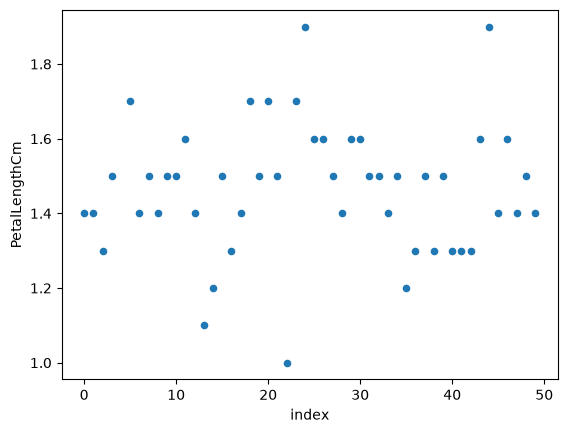

In [56]:
# # Iris-setosa  /  PetalLength
# # Ver gráfico de dispersão (pontos flutuantes)
# data_plot = data_frame
# data_plot.loc[data_frame["Species"] == "Iris-setosa"].plot.scatter(x="index", y="PetalLengthCm")

# Filtra a espécie
setosa = data_frame[data_frame["Species"] == "Iris-setosa"]

# Reseta o índice para criar uma coluna chamada 'index' e plota o gráfico
setosa.reset_index().plot.scatter(x="index", y="PetalLengthCm")


<Axes: >

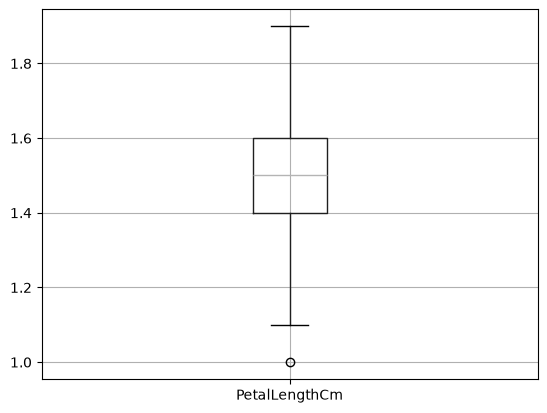

In [ ]:
# setosa = data_frame[data_frame["Species"] == "Iris-setosa"]
# setosa.reset_index().boxplot(columns="PetalLengthCm")

setosa = data_frame[data_frame["Species"] == "Iris-setosa"]

# Cria o boxplot usando 'column' no singular
setosa.boxplot(column="PetalLengthCm")


In [ ]:
# # Iris-setosa  /  PetalLengthCm
# # Describe

data_describe = setosa
data_describe.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,48.000000,50.000000,49.000000,50.00000
mean,5.022917,3.418000,1.465306,0.24400
std,0.347171,0.381024,0.175061,0.10721
min,4.300000,2.300000,1.000000,0.10000
25%,4.800000,3.125000,1.400000,0.20000
50%,5.000000,3.400000,1.500000,0.20000
75%,5.200000,3.675000,1.600000,0.30000
max,5.800000,4.400000,1.900000,0.60000


In [64]:
# Média (Mean)
mean = data_describe["PetalLengthCm"].mean()
print(mean)

data_preenchido = data_describe.copy()
data_preenchido["PetalLengthCm"] = data_preenchido["PetalLengthCm"].fillna(mean)

data_preenchido

1.4653061224489798


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.400000,0.2,Iris-setosa
1,4.9,3.0,1.400000,0.2,Iris-setosa
2,4.7,3.2,1.300000,0.2,Iris-setosa
3,4.6,3.1,1.500000,0.2,Iris-setosa
4,5.0,3.6,1.465306,0.2,Iris-setosa
5,5.4,3.9,1.700000,0.4,Iris-setosa
6,4.6,3.4,1.400000,0.3,Iris-setosa
7,5.0,3.4,1.500000,0.2,Iris-setosa
8,NaN,2.9,1.400000,0.2,Iris-setosa
9,4.9,3.1,1.500000,0.1,Iris-setosa
